## 1.Import necessary Libraries 

In [30]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

## 2.Import Dataset

In [2]:
mail_data=pd.read_csv("mail_data.csv")
mail_data

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


## 3. Data understanding

In [3]:
mail_data.shape

(5572, 2)

In [4]:
mail_data.isna().sum()

Category    0
Message     0
dtype: int64

#### In this Data set there is no null entries

In [5]:
mail_data.duplicated().sum()

np.int64(415)

In [6]:
duplicates=mail_data[mail_data.duplicated(keep=False)]
duplicates.sort_values(by="Message")

,Category,Message
2124,spam,#ERROR!
717,spam,#ERROR!
505,spam,#ERROR!
2163,ham,1) Go to write msg 2) Put on Dictionary mode 3...
1373,ham,1) Go to write msg 2) Put on Dictionary mode 3...
...,...,...
1381,ham,i dnt wnt to tlk wid u
4004,ham,somewhere out there beneath the pale moon ligh...
1412,ham,somewhere out there beneath the pale moon ligh...
2389,ham,wiskey Brandy Rum Gin Beer Vodka Scotch Shampa...


In [7]:
mail_data.drop_duplicates(inplace=True)

In [8]:
mail_data.duplicated().sum()

np.int64(0)

In [9]:
mail_data.shape

(5157, 2)

#### After, Drop the duplicates the dataset contains 5157 observations across 2 parameters

In [10]:
mail_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5157 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5157 non-null   object
 1   Message   5157 non-null   object
dtypes: object(2)
memory usage: 120.9+ KB


In [11]:
mail_data.value_counts()

Category  Message                                                                                                                                                                                                                                                                                                                                                                                                                                                                      
spam      we tried to contact you re your response to our offer of a new nokia fone and camcorder hit reply or call 08000930705 for delivery                                                                                                                                                                                                                                                                                                                                               1
ham       &lt;#&gt;  am I think? Should say on syll

### 3.1 Exploratory Data Analysis

#### 3.1.1 Class distribution chart

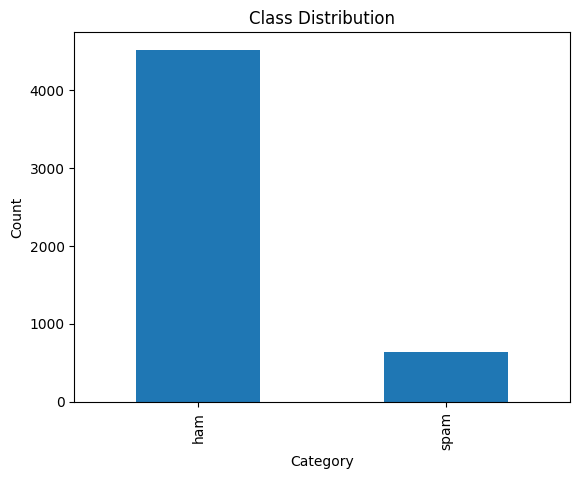

In [12]:
mail_data["Category"].value_counts().plot(kind="bar")
plt.ylabel("Count")
plt.title("Class Distribution")
plt.show()

#### 3.1.2 Analyse the Message length

In [13]:
mail_data["Message_lenghth"]=mail_data["Message"].apply(len)

In [14]:
mail_data.head()

,Category,Message,Message_lenghth
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


##### Now,check the category wise average length 

In [15]:
mail_data.groupby(by="Category")["Message_lenghth"].mean()

Category
ham      70.869353
spam    137.118565
Name: Message_lenghth, dtype: float64

##### Here,we can understand clearly understand the spam message length was to high compared to normal message

#### Visualization

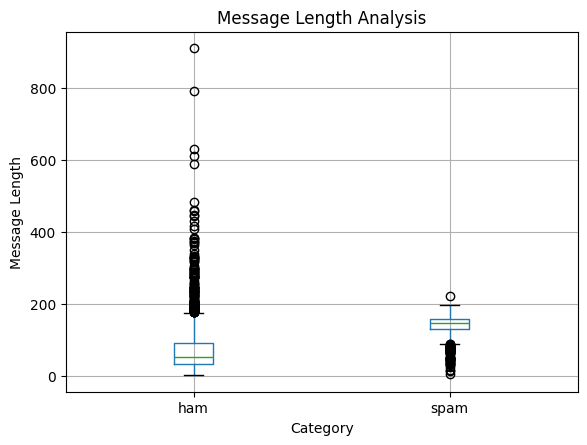

In [16]:
mail_data.boxplot(column="Message_lenghth",by="Category")
plt.ylabel("Message Length")
plt.suptitle("")
plt.title("Message Length Analysis")
plt.show()

### 4. Data Preparation

#### To Convert the Ham and Spam into 0 and 1 

In [17]:
mail_data["Category"]=mail_data["Category"].map({"ham":0,"spam":1})

In [18]:
mail_data.head()

,Category,Message,Message_lenghth
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


### Split the Input and Output for model prediction

In [25]:
X=mail_data["Message"]
X

0       Go until jurong point, crazy.. Available only ...
1                           Ok lar... Joking wif u oni...
2       Free entry in 2 a wkly comp to win FA Cup fina...
3       U dun say so early hor... U c already then say...
4       Nah I don't think he goes to usf, he lives aro...
                              ...                        
5567    This is the 2nd time we have tried 2 contact u...
5568                 Will ü b going to esplanade fr home?
5569    Pity, * was in mood for that. So...any other s...
5570    The guy did some bitching but I acted like i'd...
5571                           Rofl. Its true to its name
Name: Message, Length: 5157, dtype: object

In [26]:
Y=mail_data["Category"]
Y

0       0
1       0
2       1
3       0
4       0
       ..
5567    1
5568    0
5569    0
5570    0
5571    0
Name: Category, Length: 5157, dtype: int64

In [27]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

### 5.TF-IDF vectorization

In [28]:
vectorizer=TfidfVectorizer()

X_train=vectorizer.fit_transform(X_train)
X_test=vectorizer.transform(X_test)

### 6.Model Building

#### 6.1 Create model

In [32]:
Model=LogisticRegression()
Model


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


#### 6.2 Train model

In [33]:
Model.fit(X_train,Y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


#### 6.3 Model Prediction

In [34]:
Y_predict=Model.predict(X_test)

In [36]:
print(Y_predict)

[0 1 0 ... 0 0 0]
